In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [18]:
iris = load_iris()
x = iris.data
y = iris.target
x_train , x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [19]:
model1 = KNeighborsClassifier(n_neighbors=1)
model1.fit(x_train,y_train)
pred1 = model1.predict(x_test)

In [20]:
model2 = KNeighborsClassifier(n_neighbors=3)
model2.fit(x_train,y_train)
pred2 = model2.predict(x_test)

In [21]:
model3 = KNeighborsClassifier(n_neighbors=5)
model3.fit(x_train,y_train)
pred3 = model3.predict(x_test)

In [22]:
model4 = KNeighborsClassifier(n_neighbors=10)
model4.fit(x_train,y_train)
pred4 = model4.predict(x_test)

In [23]:
print('accuracy 1', accuracy_score(y_test, pred1))
print('accuracy 2', accuracy_score(y_test, pred2))
print('accuracy 3', accuracy_score(y_test, pred3))
print('accuracy 4', accuracy_score(y_test, pred4))

accuracy 1 1.0
accuracy 2 1.0
accuracy 3 1.0
accuracy 4 1.0


## evaluation 

In [34]:
print('confusion_matrix :', confusion_matrix(y_test, pred2))
print('\n classification report :', classification_report(y_test, pred2))

confusion_matrix : [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

 classification report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## visualization

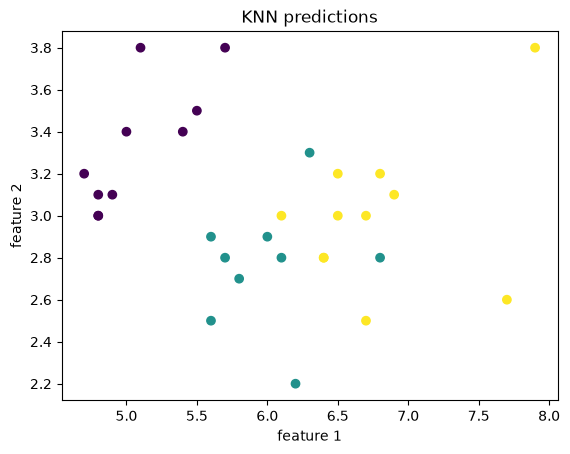

In [37]:
plt.scatter(x_test[:, 0],
            x_test[:,1], c=pred2)
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.title('KNN predictions')

plt.show()

In [26]:
for k in [1,3,5,7,9,11]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(x_train, y_train)
    prediction = model.predict(x_test)
    accuracy = accuracy_score(y_test, prediction)
    print('k =', k, 'accuracy = ', accuracy)

k = 1 accuracy =  1.0
k = 3 accuracy =  1.0
k = 5 accuracy =  1.0
k = 7 accuracy =  0.9666666666666667
k = 9 accuracy =  1.0
k = 11 accuracy =  1.0


## GridSearchCV

In [27]:
param_grid = {
    'n_neighbors': [1,3,5,7,9,11]
}

In [29]:
grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy'
)

In [30]:
grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [1, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with hig

In [31]:
print('best parameters:', grid.best_params_)
print('best score:', grid.best_score_)

best parameters: {'n_neighbors': 3}
best score: 0.9583333333333334
